## ComplyPilot JB - Final LangGraph State & Node Flow

### 0. 미션

이번 LangGraph 설계의 목표는 금융 대고객 콘텐츠를 업로드하면 AI Agent가 준법 리스크를 1차 검토하고, 근거 검색·수정안 생성·Guardrail 검증·조건부 Routing까지 수행하는 최종 Workflow를 검증하는 것이다.

ComplyPilot JB는 단순한 문구 탐지기가 아니라, 하나의 Agent State를 공유하는 여러 노드가 순차적으로 상태를 업데이트하고, 리스크 등급과 Guardrail 결과에 따라 다음 실행 경로를 선택하는 Routing + Reflection Hybrid Graph 구조를 가진다.

최종 목표 흐름은 다음과 같다.

input text/file
→ file intake
→ extract text
→ detect product/channel/language
→ user confirmation
→ map review criteria
→ detect risks
→ check missing disclaimers
→ retrieve evidence
→ judge risk
→ generate rewrite
→ check guardrail
→ route next action
→ report / retrieve retry / rewrite retry / HITL
→ save result
→ end

본 그래프의 핵심 목적은 다음과 같다.

금융 광고·마케팅 콘텐츠의 위험 표현과 필수 고지 누락 가능성을 탐지한다.
공개 금융규제 문서와 광고 가이드라인에서 관련 근거를 검색한다.
리스크 등급을 High / Medium / Low / Pass로 산정한다.
위험 문구에 대한 수정안과 필수 고지 문구를 생성한다.
AI가 생성한 수정안과 판단 결과를 Guardrail Checker로 재검증한다.
근거 부족 또는 수정안 오류가 발생하면 재검색 또는 재작성 루프로 되돌린다.
고위험, 근거 부족, 재시도 초과, OCR 불확실 건은 준법관리자 검토 대상으로 전환한다.

### 1. 최종 LangGraph 구조

ComplyPilot JB의 최종 그래프는 다음과 같은 노드로 구성된다.

__start__
→ file_intake
→ text_extractor
→ content_auto_detector
→ user_confirmation
→ review_criteria_mapper
→ risk_detector
→ disclaimer_checker
→ evidence_retriever
→ risk_judge
→ rewrite_generator
→ guardrail_checker
→ routing

routing 노드 이후에는 조건에 따라 다음 경로로 분기한다.

routing
├─ report   → report_output → save_result → __end__
├─ hitl     → hitl_review → save_result → __end__
├─ retrieve → evidence_retriever 재검색 루프
└─ rewrite  → rewrite_generator 재작성 루프

이 구조는 단순 순차 그래프가 아니라, 리스크 등급과 Guardrail 상태에 따라 실행 경로가 달라지는 Routing Graph이며, 동시에 근거 부족·수정안 오류 발생 시 재검색/재작성 루프를 수행하는 Reflection 구조를 포함한다.

<style>
  img[alt="complypilot-flow"] { width: 40%; height: auto; }
</style>

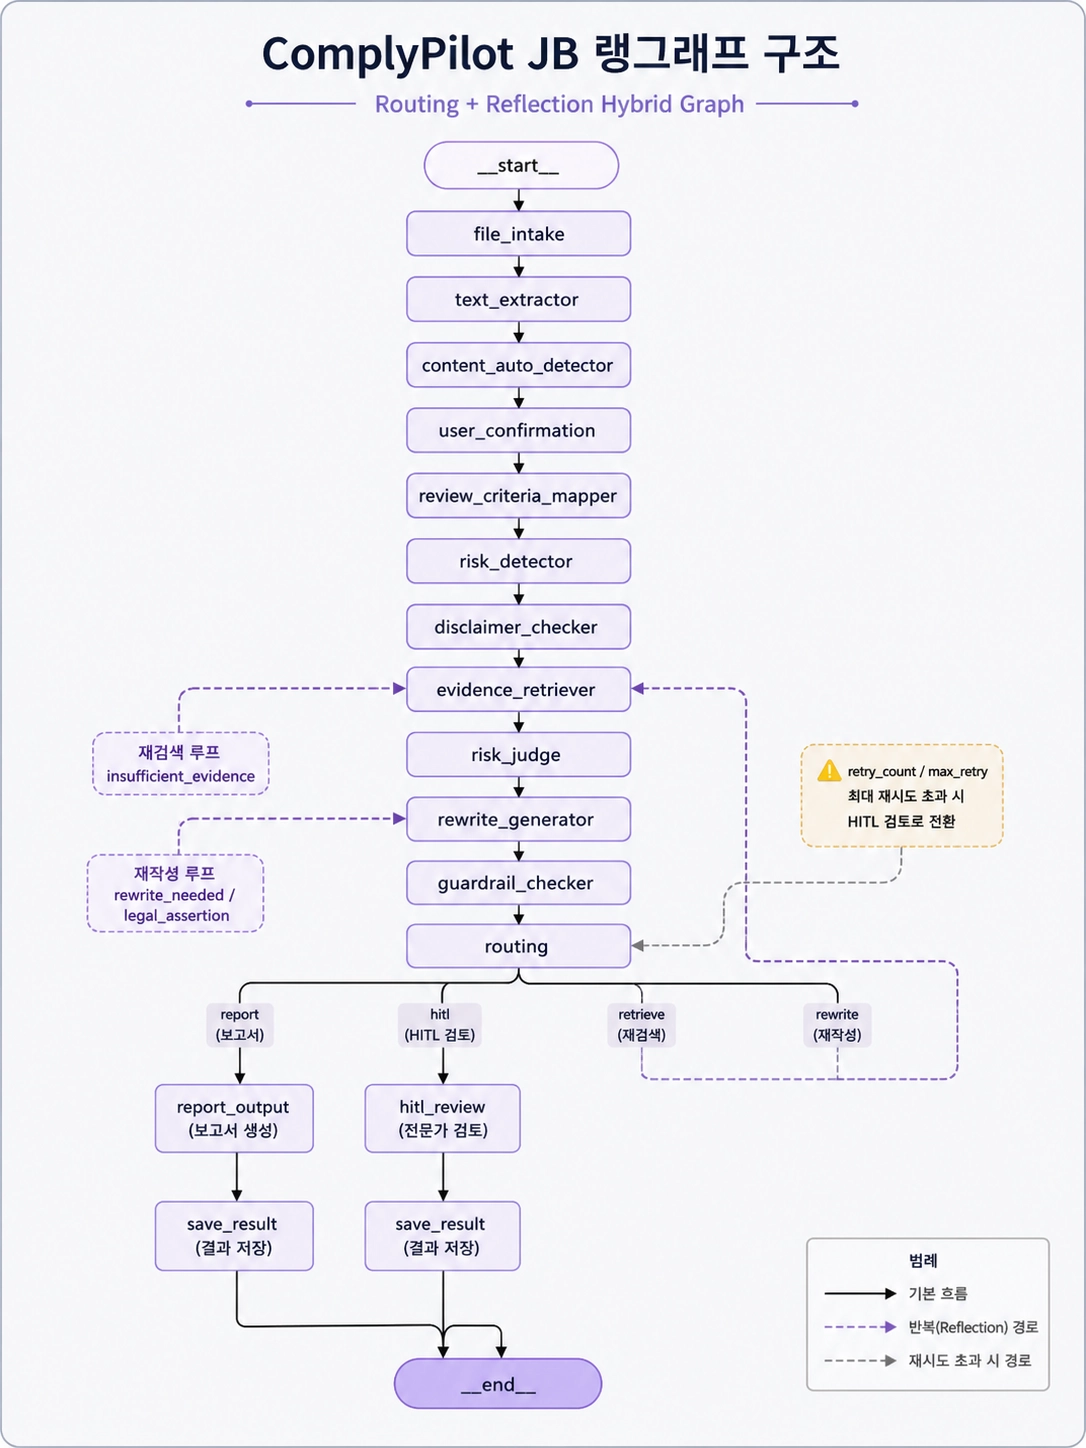

### 2. 환경 준비
2-1. 라이브러리 로딩
목적: LangGraph Workflow 구현에 필요한 기본 라이브러리 로딩
입력: 없음
출력: Python 실행 환경
처리:
typing, pathlib, json, re, pandas 로딩
LangGraph의 StateGraph, START, END 로딩
필요 시 PDF, DOCX, OCR, RAG 관련 라이브러리 로딩
2-2. 프로젝트 경로 설정
목적: 노트북에서 프로젝트 내부 모듈과 데이터 파일을 안정적으로 불러오기
입력: 현재 노트북 경로
출력: PROJECT_ROOT
처리:
프로젝트 루트 경로 설정
core/, graph/, data/ 경로 import 가능하게 구성
JSON 룰 파일과 규정 문서 경로 확인

### 3. Agent State Schema

각 노드는 하나의 ComplianceState를 공유한다.
이전 노드의 처리 결과는 State에 저장되고, 다음 노드는 해당 State를 이어받아 자신이 담당하는 필드만 업데이트한다.

목적: 전체 Agent Workflow에서 공유되는 상태값 정의
입력: 없음
출력: ComplianceState
처리:
파일 정보, 추출 텍스트, 상품/채널/언어 탐지 결과 저장
사용자 확인값과 검토 기준 저장
위험 표현, 누락 고지, RAG 근거, 리스크 등급 저장
수정안, Guardrail 결과, Routing 결과, 최종 Report 저장
재검색·재작성 반복 횟수와 HITL 필요 여부 저장

주요 State 항목은 다음과 같다.

File/Input:
- uploaded_file
- file_name
- file_type

Extraction:
- raw_text
- ocr_text
- extracted_text
- extraction_confidence

Detection:
- detected_product_type
- detected_channel
- detected_language
- confirmed_product_type
- confirmed_channel
- confirmed_language

Review:
- review_criteria
- optional_conditions
- sentences
- detected_risks
- missing_disclaimers

Evidence/Judgment:
- evidence_list
- evidence_score
- risk_level
- risk_reason
- review_required

Output/Control:
- rewrite_text
- required_disclaimer
- guardrail_status
- retry_count
- max_retry
- next_action
- report

In [ ]:
# 코드 작성

### 4. Node 1 - File Intake
목적: 업로드된 파일을 수집하고 파일 형식을 판별 <br>
입력: uploaded_file<br>
출력: file_name, file_type<br>
처리:<br>
파일명 추출<br>
확장자 또는 MIME type 확인<br>
PDF / DOCX / Image 지원 여부 검증<br>
지원하지 않는 형식이면 오류 상태 반환<br>
구현 방향: 룰 기반<br>
AI 사용 여부: 사용하지 않음

In [ ]:
# 코드 작성

### 5. Node 2 - Text Extractor
목적: PDF, Word, 이미지에서 분석 대상 문구 추출<br>
입력: uploaded_file, file_type<br>
출력: raw_text, ocr_text, extracted_text, extraction_confidence<br>
처리:<br>
PDF는 PyMuPDF로 텍스트 추출<br>
Word는 python-docx로 텍스트 추출<br>
이미지는 OCR로 문구 추출<br>
줄바꿈, 특수문자, 중복 공백 정리<br>
추출 신뢰도가 낮으면 extraction_check_required 후보 상태로 표시<br>
구현 방향: 문서 파서 + OCR 기반<br>
AI 사용 여부: 기본적으로 사용하지 않음

In [ ]:
# 코드 작성

### 6. Node 3 - Content Auto Detector
목적: 추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 사용 언어 자동 탐지<br>
입력: extracted_text, file_type<br>
출력: detected_product_type, detected_channel, detected_language<br>
처리:<br>
product_keywords.json 기반 상품 유형 탐지<br>
예금 / 대출 / 카드 / 투자 / 이벤트 키워드 매칭<br>
파일 형식과 문구 길이로 채널 추정<br>
한글 포함 여부로 언어 탐지<br>
애매한 경우 사용자 확인 단계로 넘김<br>
구현 방향: 룰 기반 + AI 보조 가능<br>
AI 사용 여부: 선택적으로 사용

In [1]:
# 코드 작성

### 7. Node 4 - User Confirmation
목적: 자동 탐지 결과의 오분류 방지<br>
입력: detected_product_type, detected_channel, detected_language<br>
출력: confirmed_product_type, confirmed_channel, confirmed_language<br>
처리:<br>
Streamlit 화면에 자동 탐지 결과 표시<br>
사용자가 상품 유형, 채널, 언어를 확인 또는 수정<br>
수정된 값을 이후 검토 기준 매핑에 사용<br>
구현 방향: Streamlit UI 기반<br>
AI 사용 여부: 사용하지 않음<br>

In [2]:
# 코드 작성

### 8. Node 5 - Review Criteria Mapper
목적: 상품·채널·언어에 맞는 검토 기준 선택<br>
입력: confirmed_product_type, confirmed_channel, confirmed_language<br>
출력: review_criteria<br>
처리:<br>
상품 유형별 위험 표현 사전 선택<br>
상품 유형별 필수 고지 체크리스트 선택<br>
채널별 점검 기준 매핑<br>
JSON 기준표 기반으로 결정적 룰 적용<br>
구현 방향: JSON 기준표 기반 룰 매핑<br>
AI 사용 여부: 사용하지 않음

In [3]:
# 코드 작성

### 9. Node 6 - Risk Detector
목적: 위험 표현과 조건 누락 가능성 1차 탐지<br>
입력: extracted_text, sentences, review_criteria<br>
출력: sentences, detected_risks<br>
처리:<br>
문장 단위 분리<br>
위험 표현 키워드 매칭<br>
위험 유형과 기본 리스크 등급 매핑<br>
탐지 결과에 keyword, risk_type, base_level, reason, matched_sentence 저장<br>
AI는 최종 판단이 아니라 문맥 후보 보조에만 사용 가능<br>
구현 방향: Rule-based Detector<br>
AI 사용 여부: 선택적으로 문맥 후보 탐지에만 사용

In [4]:
# 코드 작성

### 10. Node 7 - Disclaimer Checker
목적: 상품 유형별 필수 고지 누락 가능성 검토<br>
입력: extracted_text, review_criteria<br>
출력: missing_disclaimers<br>
처리:<br>
필수 고지 체크리스트 로딩<br>
추출 문구에 필수 고지 항목 포함 여부 확인<br>
누락 가능성이 있는 항목을 리스트로 저장<br>
예: 금리 조건, 수수료 조건, 전월 실적, 원금 손실 가능성 등<br>
구현 방향: Checklist Matching<br>
AI 사용 여부: 사용하지 않음

In [ ]:
# 코드 작성

### 11. Node 8 - Evidence Retriever
목적: 탐지된 위험 유형에 맞는 규정 근거 검색<br>
입력: detected_risks, missing_disclaimers, confirmed_product_type<br>
출력: evidence_list, evidence_score<br>
처리:<br>
위험 유형 기반 검색 Query 생성<br>
규정 문서 Chunk 검색<br>
Chroma Vector DB 또는 BM25 검색 사용<br>
Top-K 근거 스니펫 반환<br>
근거 부족 시 JSON fallback 검색<br>
근거가 없으면 억지 생성하지 않고 insufficient_evidence 흐름으로 전달<br>
구현 방향: RAG / BM25 / Vector Search<br>
AI 사용 여부: 직접 생성형 AI보다는 검색 중심

In [ ]:
# 코드 작성

### 12. Node 9 - Risk Judge
목적: 탐지 결과와 근거 충분성을 바탕으로 최종 리스크 등급 산정<br>
입력: detected_risks, missing_disclaimers, evidence_list, evidence_score<br>
출력: risk_level, risk_reason, review_required<br>
처리:<br>
High 위험이 하나라도 있으면 High<br>
Medium 위험 또는 필수 고지 누락이 있으면 Medium<br>
경미한 확인 필요 사항은 Low<br>
위험이 없으면 Pass<br>
High 또는 근거 부족이면 review_required = True<br>
리스크 등급은 LLM이 아니라 룰 기반으로 결정<br>
구현 방향: Rule-based Judge<br>
AI 사용 여부: 사용하지 않음<br>
주의점: 최종 법률 판단이 아니라 준법 검토 보조 판단임

In [ ]:
# 코드 작성

### 13. Node 10 - Rewrite Generator
목적: 위험 문구를 완화하고 필수 고지를 반영한 수정안 생성<br>
입력: extracted_text, detected_risks, missing_disclaimers, evidence_list,<br> risk_level
출력: rewrite_text, required_disclaimer<br>
처리:<br>
위험 유형별 템플릿 수정안 생성<br>
누락된 필수 고지 문구 추가<br>
OpenAI API 사용 가능 시 문장 자연화<br>
API 실패 시 템플릿 기반 수정안 유지<br>
법률 단정 표현이 포함되지 않도록 Guardrail 단계로 전달<br>
구현 방향: OpenAI 연결 + Template fallback<br>
AI 사용 여부: 문장 자연화에만 사용

In [ ]:
# 코드 작성

### 14. Node 11 - Guardrail Checker
목적: 수정안과 판단 결과가 안전한지 검증<br>
입력: rewrite_text, evidence_list, risk_reason, risk_level, detected_risks, extraction_confidence<br>
출력: guardrail_status, needs_hitl, needs_rewrite, needs_retrieval_retry<br>
처리:<br>
근거 부족 여부 확인<br>
법률 단정 표현 탐지<br>
수정안에 위험 표현이 남아 있는지 확인<br>
OCR 또는 텍스트 추출 신뢰도 확인<br>
문제가 있으면 insufficient_evidence, legal_assertion, rewrite_needed, extraction_check_required 중 하나로 표시<br>
구현 방향: Rule-based Guardrail<br>
AI 사용 여부: 사용하지 않음<br>
주의점: LLM이 생성한 문장도 반드시 이 노드를 통과해야 함

In [ ]:
# 코드 작성

### 15. Node 12 - Routing
목적: 현재 State 기준으로 다음 실행 경로를 결정하고, 근거 부족 또는 수정안 오류가 있으면 재검색·재작성 루프를 수행<br>
입력: risk_level, guardrail_status, evidence_score, retry_count, max_retry<br>
출력: next_action, review_required<br>
처리:<br>
Pass / Low / Medium + guardrail_status == ok → report_output
High → hitl_review<br>
insufficient_evidence + retry_count < max_retry → evidence_retriever 재검색<br>
rewrite_needed 또는 legal_assertion + retry_count < max_retry → rewrite_generator 재작성<br>
extraction_check_required → hitl_review<br>
retry_count >= max_retry → hitl_review<br>
구현 방향: Conditional Edge 기반 Routing<br>
AI 사용 여부: 사용하지 않음<br>
특징:<br>
단순 분기 그래프가 아니라 Guardrail 결과를 기반으로 재검색·재작성하는 Reflection Loop를 포함<br>
무한 반복을 방지하기 위해 retry_count와 max_retry를 사용

In [ ]:
# 코드 작성

### 16. Node 13 - Report Output
목적: 준법관리자가 확인하기 쉬운 최종 검토 리포트 생성<br>
입력: Agent State 전체<br>
출력: report<br>
처리:<br>
파일명, 상품 유형, 채널, 언어 정리<br>
추출 문구와 탐지 표현 정리<br>
위험 유형, 리스크 등급, 판단 사유 정리<br>
RAG 근거 스니펫과 출처 정리<br>
수정안과 필수 고지 문구 정리<br>
Guardrail 상태와 준법관리자 검토 필요 여부 표시<br>
JSON/CSV 저장 또는 Streamlit 표 출력에 사용할 구조로 반환<br>
구현 방향: 구조화 Report 생성<br>
AI 사용 여부: 선택적으로 요약 문장 생성에만 사용

In [ ]:
# 코드 작성

### 17. Node 14 - HITL Review
목적: 고위험, 근거 부족, OCR 불확실, 재시도 초과 건을 준법관리자 검토 대상으로 전환<br>
입력: report, risk_level, guardrail_status, review_required<br>
출력: review_status<br>
처리:<br>
준법관리자 검토 필요 건 표시<br>
자동 승인하지 않고 사람 검토 대상으로 전환<br>
예선 MVP에서는 상태 표시까지만 구현<br>
본선에서는 승인 / 수정요청 / 반려 워크플로우로 확장<br>
구현 방향: HITL 상태 관리<br>
AI 사용 여부: 사용하지 않음

In [ ]:
# 코드 작성

### 18. Node 15 - Save Result
목적: 최종 검토 결과 저장<br>
입력: report, review_status<br>
출력: saved_result<br>
처리:<br>
report를 JSON 또는 CSV로 저장<br>
저장 경로를 outputs/reports/에 기록<br>
저장 실패 시 오류 상태 반환<br>
본선에서는 감사로그, 이력관리, 권한관리로 확장<br>
구현 방향: Python 파일 저장<br>
AI 사용 여부: 사용하지 않음


### 19. Node 16 - End
목적: Agent Workflow 종료<br>
입력: saved_result<br>
출력: 최종 완료 상태<br>
처리:<br>
Report 저장 또는 HITL 전환 결과 저장 후 Workflow 종료<br>
최종 State를 반환하여 Streamlit 화면에 표시<br>
구현 방향: LangGraph END 노드 연결

### 20. 최종 완료 기준

최종 LangGraph는 다음 조건을 만족하면 완료로 본다.<br>

PDF / DOCX / 이미지 / 텍스트 입력을 받을 수 있다.<br>
입력 파일에서 분석 대상 문구를 추출할 수 있다.<br>
상품 유형, 콘텐츠 채널, 사용 언어를 자동 탐지할 수 있다.<br>
사용자가 자동 탐지 결과를 확인 또는 수정할 수 있다.<br>
상품·채널·언어 기준에 맞는 검토 기준을 매핑할 수 있다.<br>
위험 표현과 필수 고지 누락 가능성을 탐지할 수 있다.<br>
관련 규정 근거를 RAG 또는 fallback 방식으로 검색할 수 있다.<br>
High / Medium / Low / Pass 리스크 등급을 산정할 수 있다.<br>
위험 문구에 대한 수정안과 필수 고지 문구를 생성할 수 있다.<br>
Guardrail Checker가 근거 부족, 법률 단정 표현, 수정안 오류, OCR 불확실성을 검증할 수 있다.<br>
Routing 노드가 report / retrieve / rewrite / hitl 중 다음 경로를 선택할 수 있다.<br>
근거 부족 시 evidence_retriever로 재검색할 수 있다.<br>
수정안 오류 시 rewrite_generator로 재작성할 수 있다.<br>
재시도 초과 또는 고위험 건은 hitl_review로 전환할 수 있다.<br>
최종 결과를 report_output으로 구조화하고 save_result로 저장할 수 있다.<br>
전체 Workflow가 LangGraph에서 정상 실행된다.